In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms

# Import Model
from models.CNN.CNN_a import CNN

# Import utils
from utils.train_val_utils import train_and_evaluate
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_utils import load_best_model
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


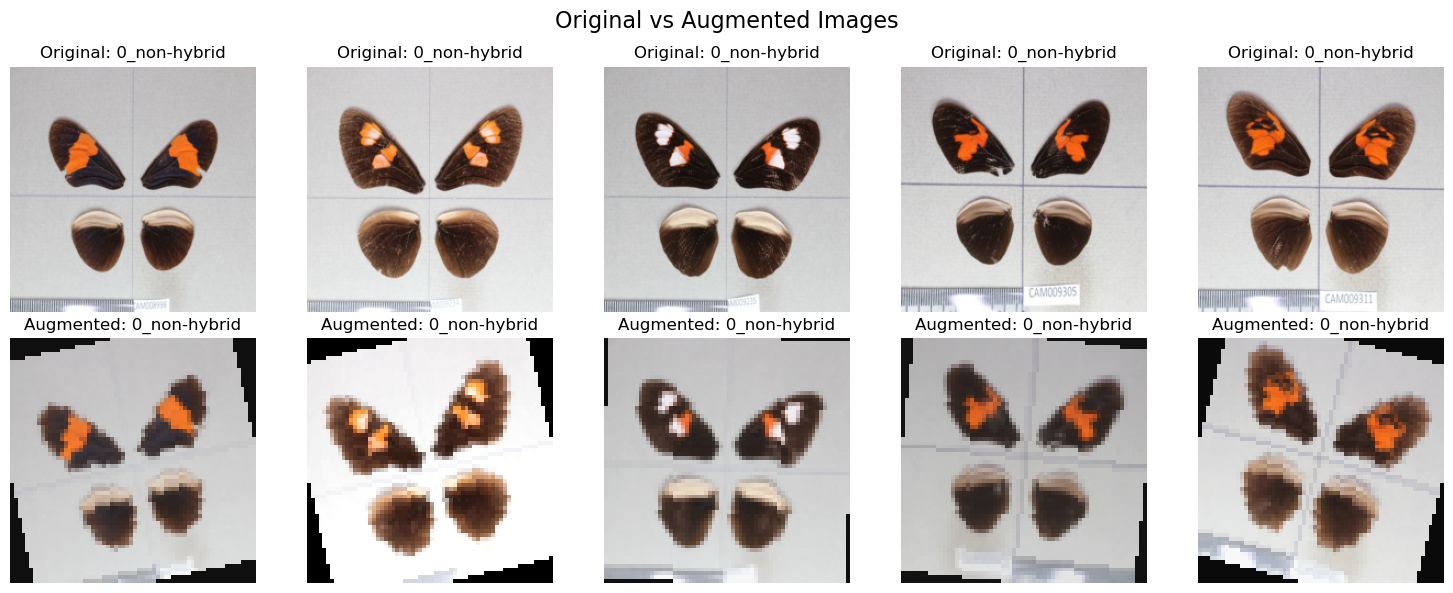

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [6]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
class_weights_values = [2.5, 3.5, 4.5, 5.5]
batch_size_values = [16, 32, 64, 128]

model_cnn_a_dict = {}
optimizer_a_dict = {}
results_a_dict = {}
best_a_dict = {}
best_f2_a_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_class_weights_val_dict = {}
best_batch_size_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_class_weights_val = 2.5
best_batch_size = 16

best_f2 = float("-inf")

# Hyperparameter tuning loop for learning rate
for learning_rate in learning_rate_values:
    model_cnn_a_dict[f"model_cnn_a{count}"] = CNN(num_classes=2).to(device)
    optimizer_a_dict[f"optimizer_a{count}"] = optim.Adam(model_cnn_a_dict[f"model_cnn_a{count}"].parameters(), lr=learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining CNN Model A{count} with learning rate {learning_rate}")
    results_a_dict[f"results_a{count}"] = train_and_evaluate(model_cnn_a_dict[f"model_cnn_a{count}"], train_dataset_aug, val_dataset, optimizer_a_dict[f"optimizer_a{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl", device=device, num_workers=0)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_cnn_a_dict[f"model_cnn_a{count}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_a{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_a{count}"] = best_batch_size
    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]

# Hyperparameter tuning loop for weight decay
for weight_decay in weight_decay_values[1:]:
    model_cnn_a_dict[f"model_cnn_a{count}"] = CNN(num_classes=2).to(device)
    optimizer_a_dict[f"optimizer_a{count}"] = optim.Adam(model_cnn_a_dict[f"model_cnn_a{count}"].parameters(), lr=best_learning_rate, weight_decay=weight_decay)
    print(f"\nTraining CNN Model A{count} with weight decay {weight_decay}")
    results_a_dict[f"results_a{count}"] = train_and_evaluate(model_cnn_a_dict[f"model_cnn_a{count}"], train_dataset_aug, val_dataset, optimizer_a_dict[f"optimizer_a{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl", device=device, num_workers=0)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_cnn_a_dict[f"model_cnn_a{count}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_a{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_a{count}"] = best_batch_size
    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]

# Hyperparameter tuning loop for class weights
for class_weights_val in class_weights_values[1:]:
    model_cnn_a_dict[f"model_cnn_a{count}"] = CNN(num_classes=2).to(device)
    optimizer_a_dict[f"optimizer_a{count}"] = optim.Adam(model_cnn_a_dict[f"model_cnn_a{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining CNN Model A{count} with class weights {class_weights_val}")
    results_a_dict[f"results_a{count}"] = train_and_evaluate(model_cnn_a_dict[f"model_cnn_a{count}"], train_dataset_aug, val_dataset, optimizer_a_dict[f"optimizer_a{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=class_weights_val, ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl", device=device, num_workers=0)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_cnn_a_dict[f"model_cnn_a{count}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_a{count}"] = class_weights_val
    best_batch_size_dict[f"best_batch_size_a{count}"] = best_batch_size
    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_class_weights_val = class_weights_val
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]

# Hyperparameter tuning loop for batch size
for batch_size in batch_size_values[1:]:
    model_cnn_a_dict[f"model_cnn_a{count}"] = CNN(num_classes=2).to(device)
    optimizer_a_dict[f"optimizer_a{count}"] = optim.Adam(model_cnn_a_dict[f"model_cnn_a{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining CNN Model A{count} with batch size {batch_size}")
    results_a_dict[f"results_a{count}"] = train_and_evaluate(model_cnn_a_dict[f"model_cnn_a{count}"], train_dataset_aug, val_dataset, optimizer_a_dict[f"optimizer_a{count}"], num_epochs=30, batch_size=batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl", device=device, num_workers=0)
    best_a_dict[f"best_a{count}"], best_f2_a_dict[f"best_f2_a{count}"] = show_best_model(model_cnn_a_dict[f"model_cnn_a{count}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_a{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_a{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_a{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_a{count}"] = batch_size
    count += 1
    if best_f2_a_dict[f"best_f2_a{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_a_dict[f"best_f2_a{count-1}"]


Training CNN Model A1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.702128
  [Epoch 4] Improvement! New best score: 0.758929
  [Epoch 5] Improvement! New best score: 0.769231
Epoch [5/30], Train Loss: 0.4218, Val Loss: 0.4295, Train F1-Macro: 0.7118, Val F1-Macro: 0.7391, Train F1-Per-Class: [0.85296905 0.5706371 ], Val F1-Per-Class: [0.86838126 0.6098655 ], Train F2-Macro: 0.7596, Val F2-Macro: 0.7904, Train F2-Per-Class: [0.7953018  0.72392464], Val F2-Per-Class: [0.8116516 0.7692308], No improvement: 0/6
Epoch [5/30], Train Loss: 0.4218, Val Loss: 0.4295, Train F1-Macro: 0.7118, Val F1-Macro: 0.7391, Train F1-Per-Class: [0.85296905 0.5706371 ], Val F1-Per-Class: [0.86838126 0.6098655 ] Train F2-Macro: 0.7596, Val F2-Macro: 0.7904, Train F2-Per-Class: [0.7953018  0.72392464], Val F2-Per-Class: [0.8116516 0.7692308]
Epoch [10/30], Train Loss: 0.3972, Val Loss: 0.6982, Train F1-Macro: 0.6131, Val F1-Macro: 0.6646, Train F1-Per-Class: [0.75218296 0.47396293], Val F

In [8]:
# Restore best hyperparameters for model_a
best_learning_rate_dict = {'best_learning_rate_a1': 0.01, 'best_learning_rate_a2': 0.005, 'best_learning_rate_a3': 0.001, 'best_learning_rate_a4': 0.0001, 'best_learning_rate_a5': 0.005, 'best_learning_rate_a6': 0.005, 'best_learning_rate_a7': 0.005, 'best_learning_rate_a8': 0.005, 'best_learning_rate_a9': 0.005, 'best_learning_rate_a10': 0.005, 'best_learning_rate_a11': 0.005, 'best_learning_rate_a12': 0.005, 'best_learning_rate_a13': 0.005}
best_weight_decay_dict = {'best_weight_decay_a1': 0.001, 'best_weight_decay_a2': 0.001, 'best_weight_decay_a3': 0.001, 'best_weight_decay_a4': 0.001, 'best_weight_decay_a5': 0.0001, 'best_weight_decay_a6': 1e-05, 'best_weight_decay_a7': 1e-06, 'best_weight_decay_a8': 0.001, 'best_weight_decay_a9': 0.001, 'best_weight_decay_a10': 0.001, 'best_weight_decay_a11': 0.001, 'best_weight_decay_a12': 0.001, 'best_weight_decay_a13': 0.001}
best_class_weights_val_dict = {'best_class_weights_val_a1': 2.5, 'best_class_weights_val_a2': 2.5, 'best_class_weights_val_a3': 2.5, 'best_class_weights_val_a4': 2.5, 'best_class_weights_val_a5': 2.5, 'best_class_weights_val_a6': 2.5, 'best_class_weights_val_a7': 2.5, 'best_class_weights_val_a8': 3.5, 'best_class_weights_val_a9': 4.5, 'best_class_weights_val_a10': 5.5, 'best_class_weights_val_a11': 2.5, 'best_class_weights_val_a12': 2.5, 'best_class_weights_val_a13': 2.5}
best_batch_size_dict = {'best_batch_size_a1': 16, 'best_batch_size_a2': 16, 'best_batch_size_a3': 16, 'best_batch_size_a4': 16, 'best_batch_size_a5': 16, 'best_batch_size_a6': 16, 'best_batch_size_a7': 16, 'best_batch_size_a8': 16, 'best_batch_size_a9': 16, 'best_batch_size_a10': 16, 'best_batch_size_a11': 32, 'best_batch_size_a12': 64, 'best_batch_size_a13': 128}

# Initialize model_cnn_a_dict with CNN instances for each hyperparameter combination
model_cnn_a_dict = {
    'model_cnn_a1': CNN(num_classes=2).to(device),
    'model_cnn_a2': CNN(num_classes=2).to(device),
    'model_cnn_a3': CNN(num_classes=2).to(device),
    'model_cnn_a4': CNN(num_classes=2).to(device),
    'model_cnn_a5': CNN(num_classes=2).to(device),
    'model_cnn_a6': CNN(num_classes=2).to(device),
    'model_cnn_a7': CNN(num_classes=2).to(device),
    'model_cnn_a8': CNN(num_classes=2).to(device),
    'model_cnn_a9': CNN(num_classes=2).to(device),
    'model_cnn_a10': CNN(num_classes=2).to(device),
    'model_cnn_a11': CNN(num_classes=2).to(device),
    'model_cnn_a12': CNN(num_classes=2).to(device),
    'model_cnn_a13': CNN(num_classes=2).to(device)
}

best_a_dict = {}
best_f2_a_dict = {}

In [9]:
for i in range(1, 8):
    print(
        f"Model A{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_a{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_a{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_a{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_a{i}']} | "
    )
    best_a_dict[f"best_a{i}"], best_f2_a_dict[f"best_f2_a{i}"] = show_best_model(model=model_cnn_a_dict[f"model_cnn_a{i}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{i}_log.pkl")

Model A1 | lr=0.01 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 5
Best val F2(class 0): 0.8116515874862671
Best val F2(class 1): 0.7692307829856873
Model A2 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 2
Best val F2(class 0): 0.8482642769813538
Best val F2(class 1): 0.7783018946647644
Model A3 | lr=0.001 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 1
Best val F2(class 0): 0.7348703145980835
Best val F2(class 1): 0.7263157963752747
Model A4 | lr=0.0001 | wd=0.001 | class_w=2.5 | bs=16 | 
Selected epoch: 1
Best val F2(class 0): 0.6787595152854919
Best val F2(class 1): 0.71856290102005
Model A5 | lr=0.005 | wd=0.0001 | class_w=2.5 | bs=16 | 
Selected epoch: 9
Best val F2(class 0): 0.7553130388259888
Best val F2(class 1): 0.7569296360015869
Model A6 | lr=0.005 | wd=1e-05 | class_w=2.5 | bs=16 | 
Selected epoch: 3
Best val F2(class 0): 0.49390244483947754
Best val F2(class 1): 0.6228070259094238
Model A7 | lr=0.005 | wd=1e-06 | class_w=2.5 | bs=16 | 
Selected

In [10]:
for i in range(8, 14):
    print(
        f"Model A{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_a{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_a{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_a{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_a{i}']} | "
    )
    best_a_dict[f"best_a{i}"], best_f2_a_dict[f"best_f2_a{i}"] = show_best_model(model=model_cnn_a_dict[f"model_cnn_a{i}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{i}_log.pkl")

Model A8 | lr=0.005 | wd=0.001 | class_w=3.5 | bs=16 | 
Selected epoch: 6
Best val F2(class 0): 0.7902216911315918
Best val F2(class 1): 0.7538802623748779
Model A9 | lr=0.005 | wd=0.001 | class_w=4.5 | bs=16 | 
Selected epoch: 4
Best val F2(class 0): 0.7917139530181885
Best val F2(class 1): 0.7366071343421936
Model A10 | lr=0.005 | wd=0.001 | class_w=5.5 | bs=16 | 
Selected epoch: 1
Best val F2(class 0): 0.7084785103797913
Best val F2(class 1): 0.7274590134620667
Model A11 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=32 | 
Selected epoch: 5
Best val F2(class 0): 0.6109133958816528
Best val F2(class 1): 0.6583969593048096
Model A12 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=64 | 
Selected epoch: 9
Best val F2(class 0): 0.7632933259010315
Best val F2(class 1): 0.726681113243103
Model A13 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=128 | 
Selected epoch: 5
Best val F2(class 0): 0.880886435508728
Best val F2(class 1): 0.7654321193695068


In [11]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_a_dict, key=lambda k: float(best_f2_a_dict[k]))
best_i = int(best_f2_key.split("a")[-1])

model = model_cnn_a_dict[f"model_cnn_a{best_i}"]
best = best_a_dict[f"best_a{best_i}"]

print(
    f"Selected Best Model A{best_i} | "
    f"val_f2_class1={float(best_f2_a_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_a{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_a{best_i}']} | "
    f"class_w={best_class_weights_val_dict[f'best_class_weights_val_a{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_a{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model(best_model=model, best=best, test_dataset=test_dataset, device=device)

Selected Best Model A2 | val_f2_class1=0.778302 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16
Test loss: 0.4029690554099424
Test F2 macro: 0.7993611693382263
Test F2 per class: [0.8365976 0.7621247]
Test F2 for class 1 (1_hybrid): 0.7621247172355652


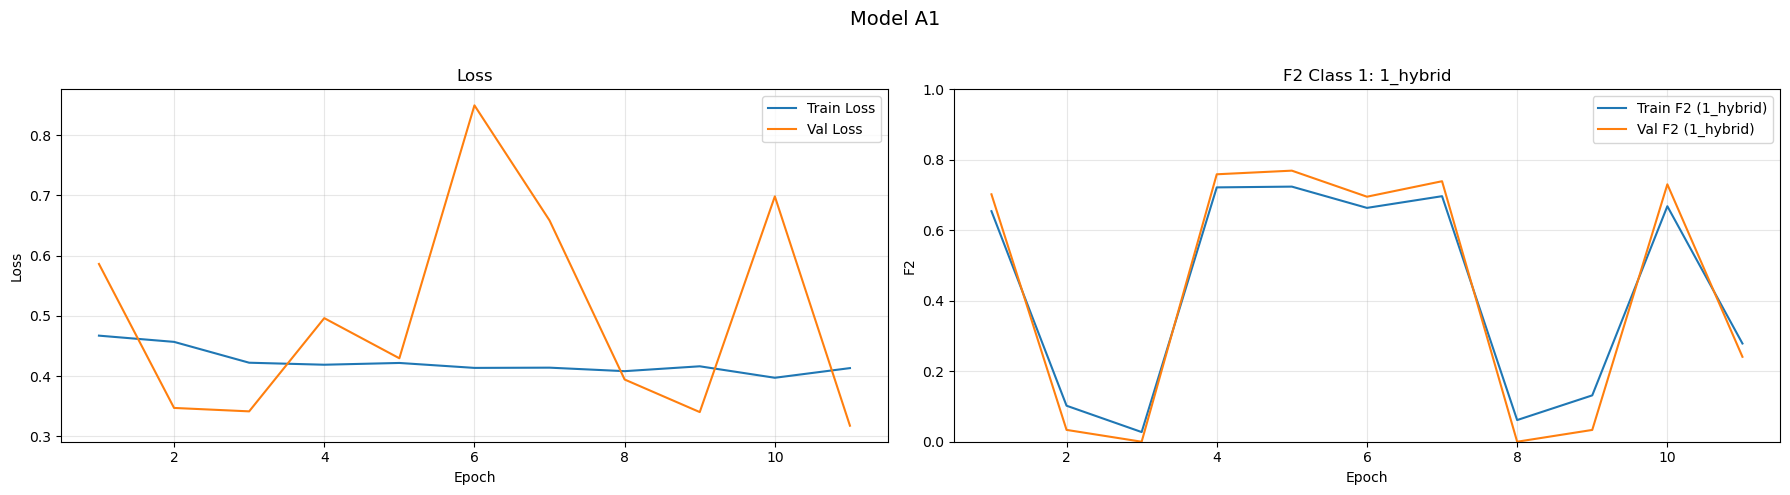

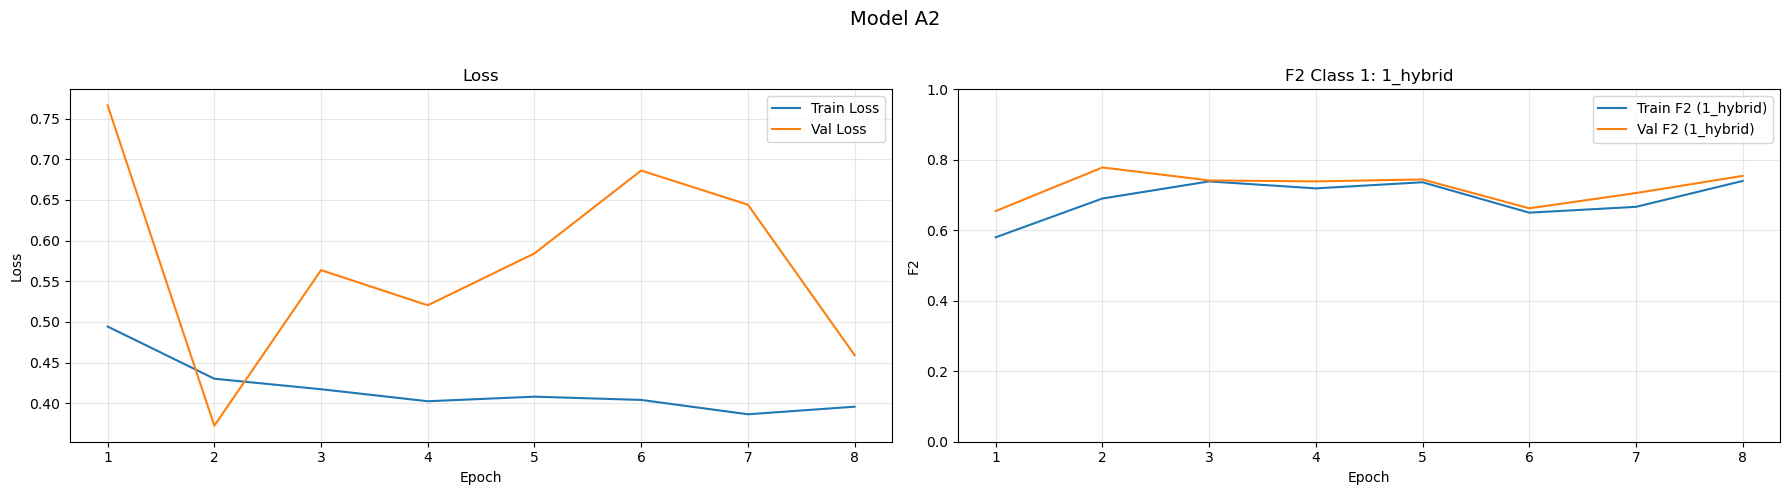

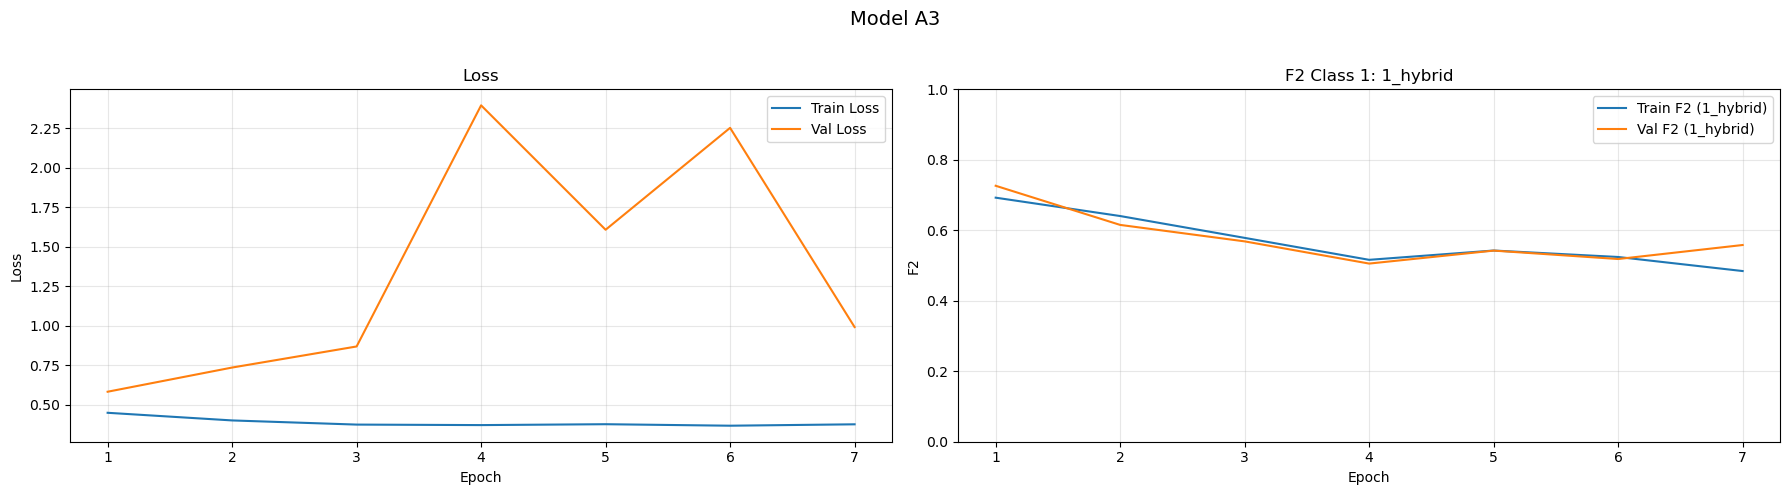

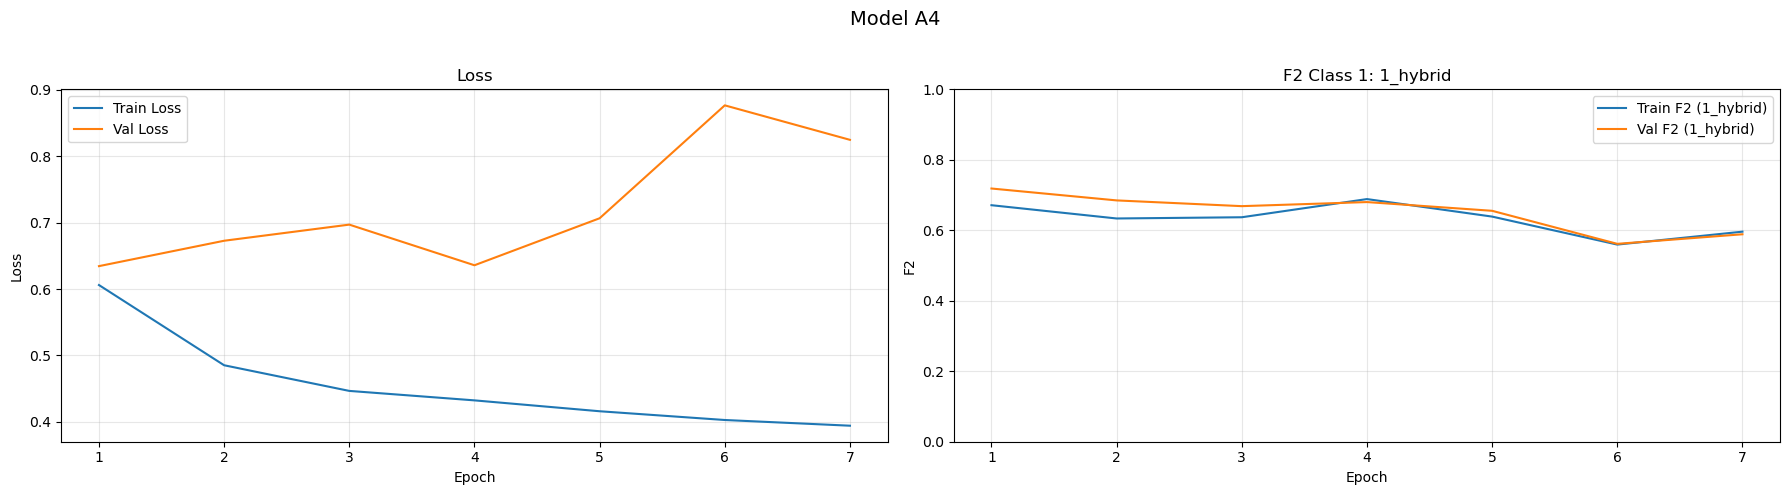

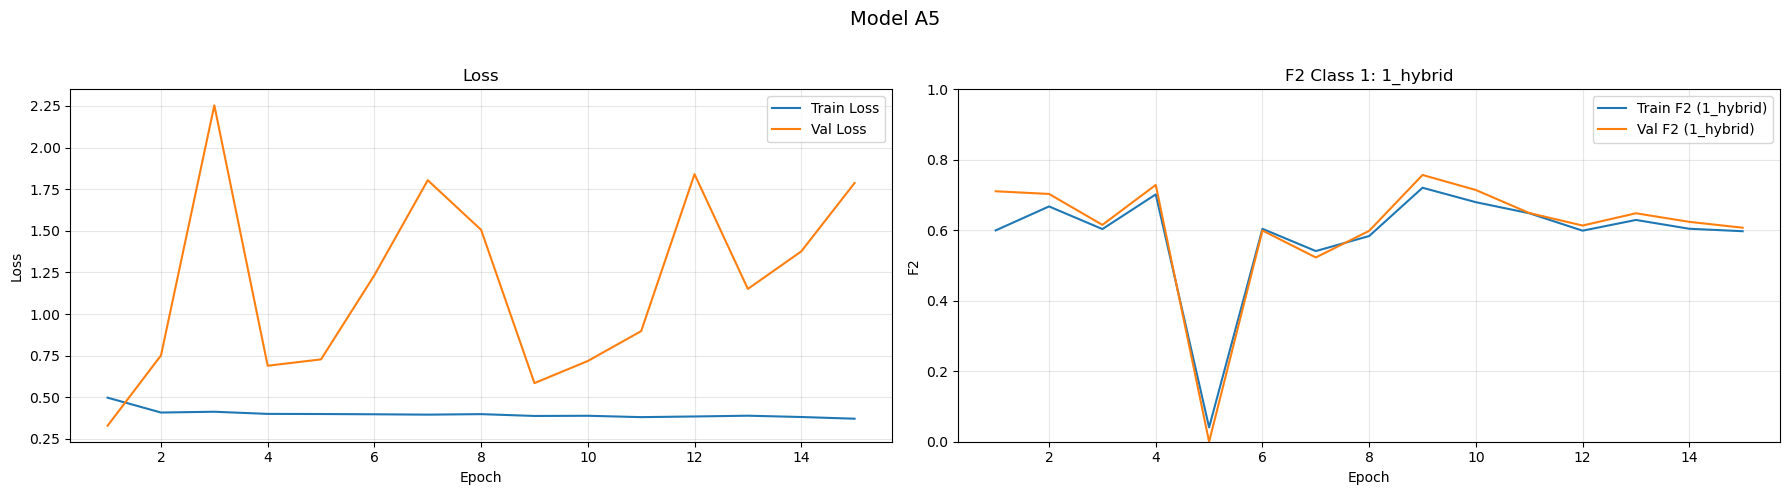

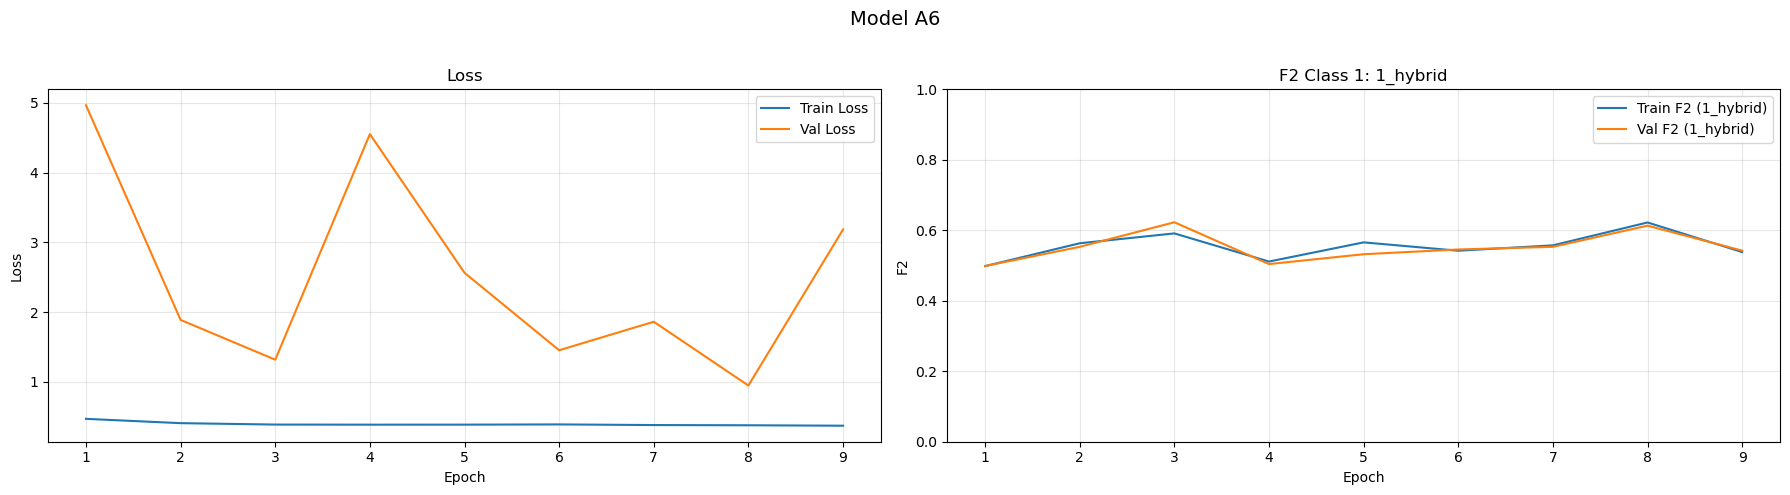

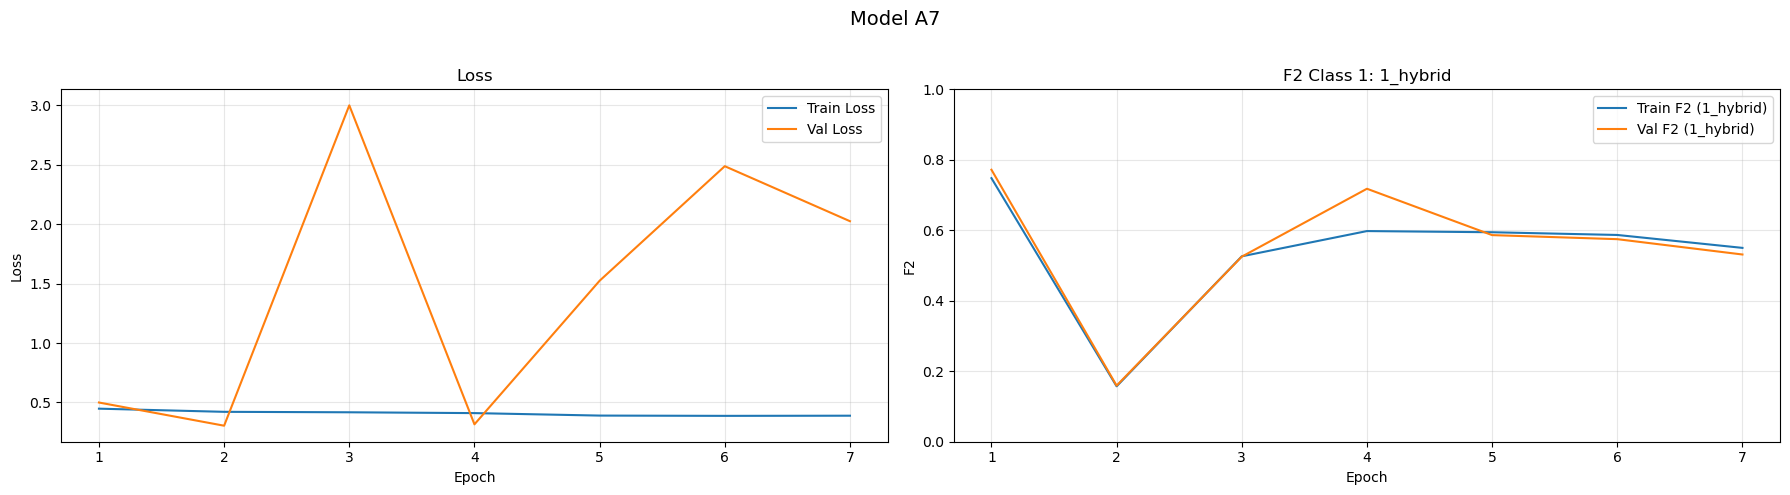

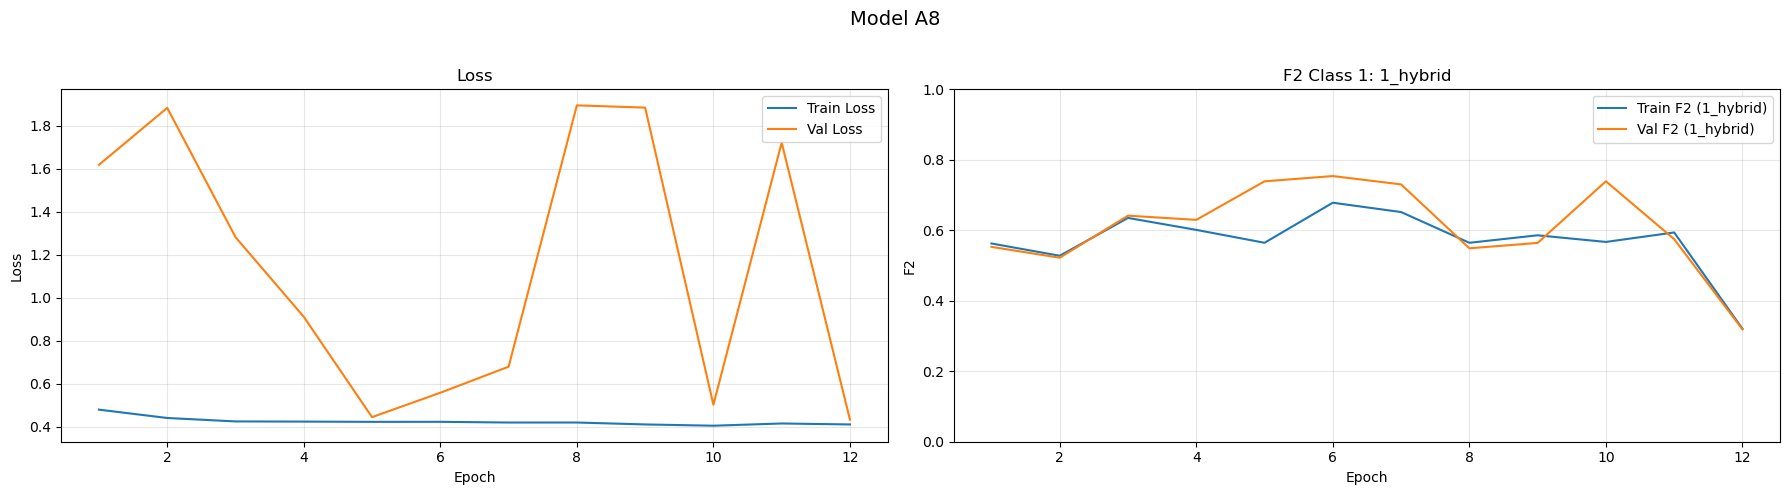

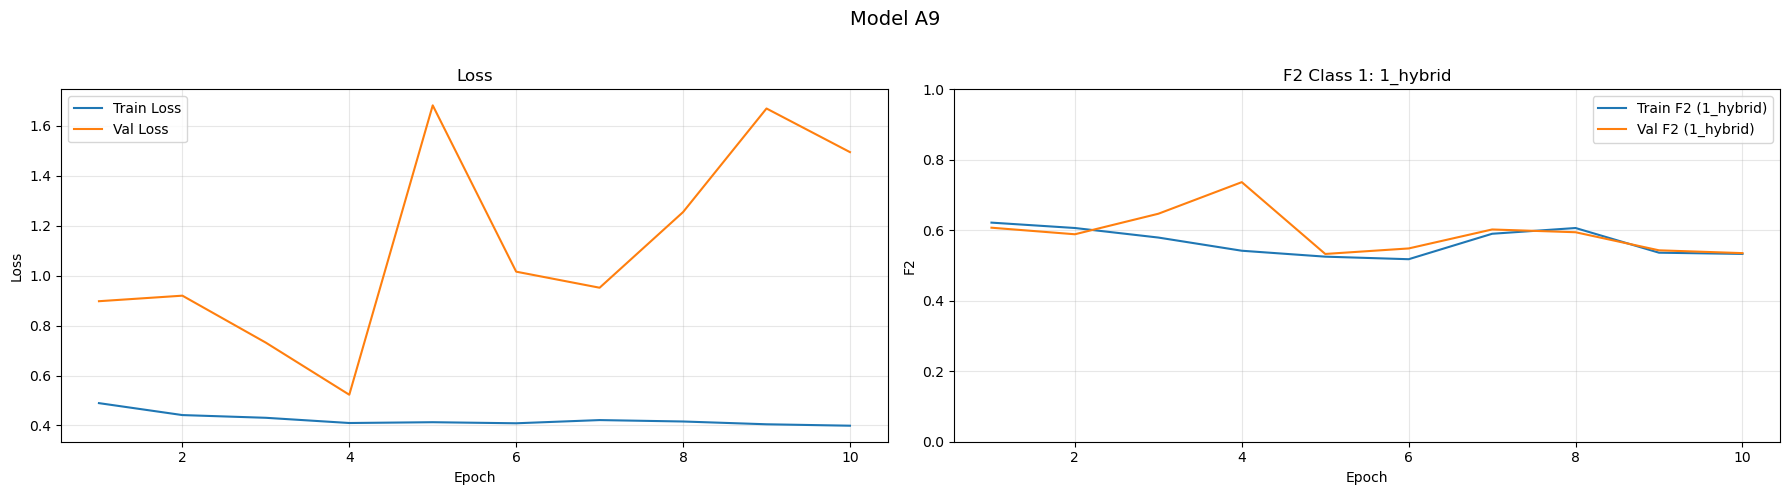

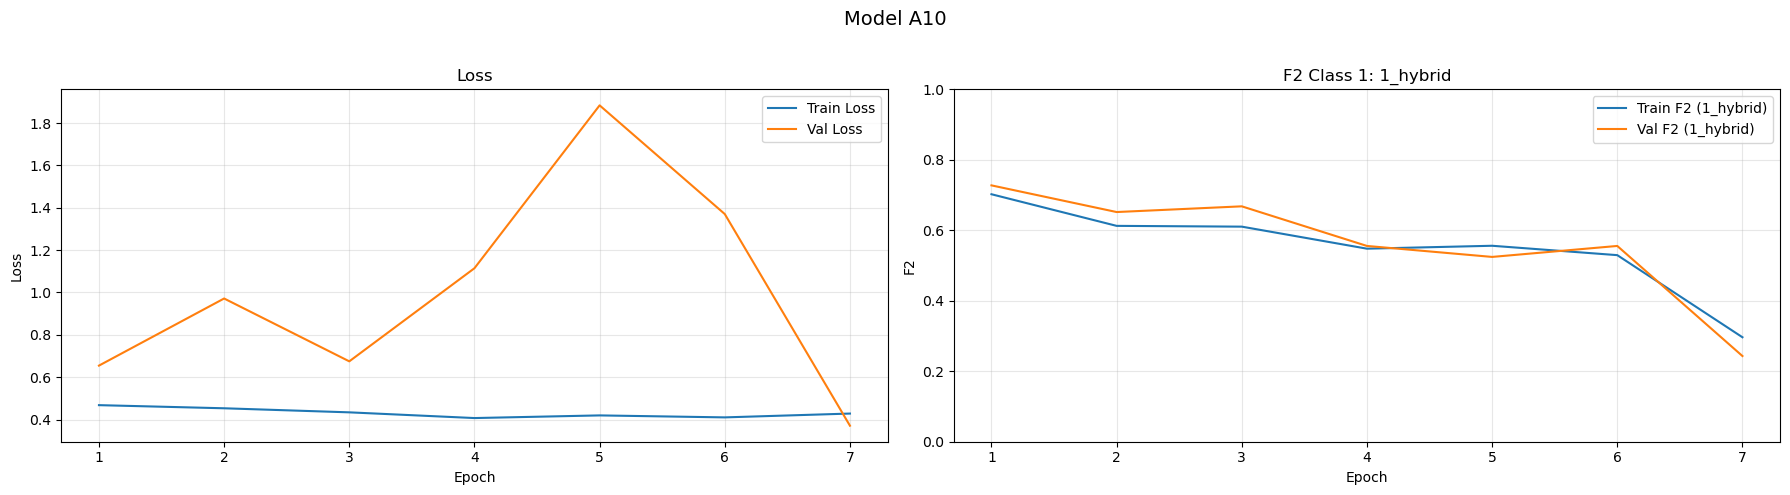

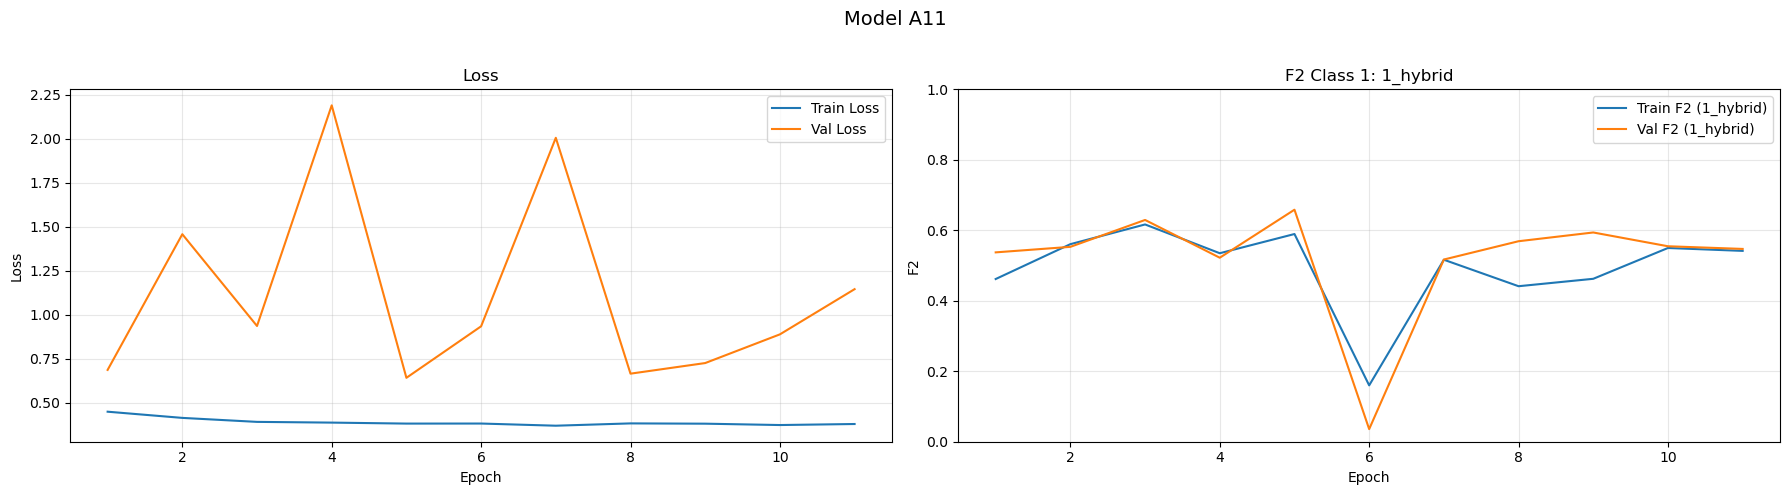

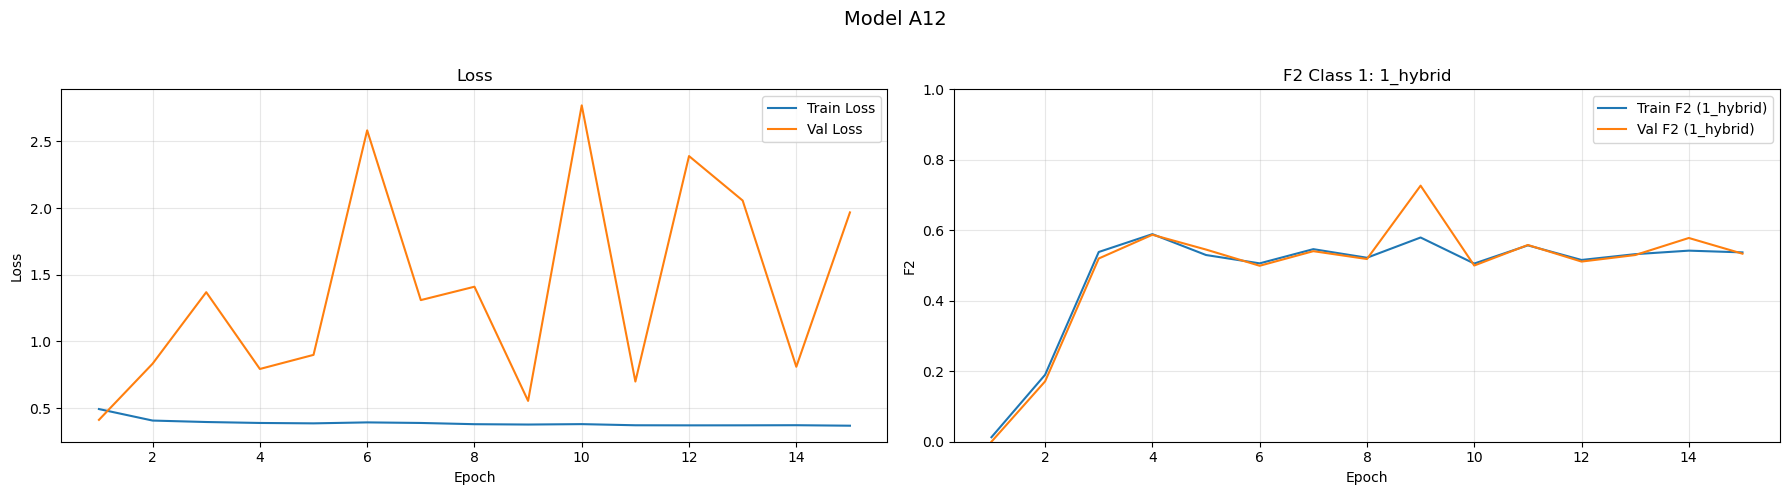

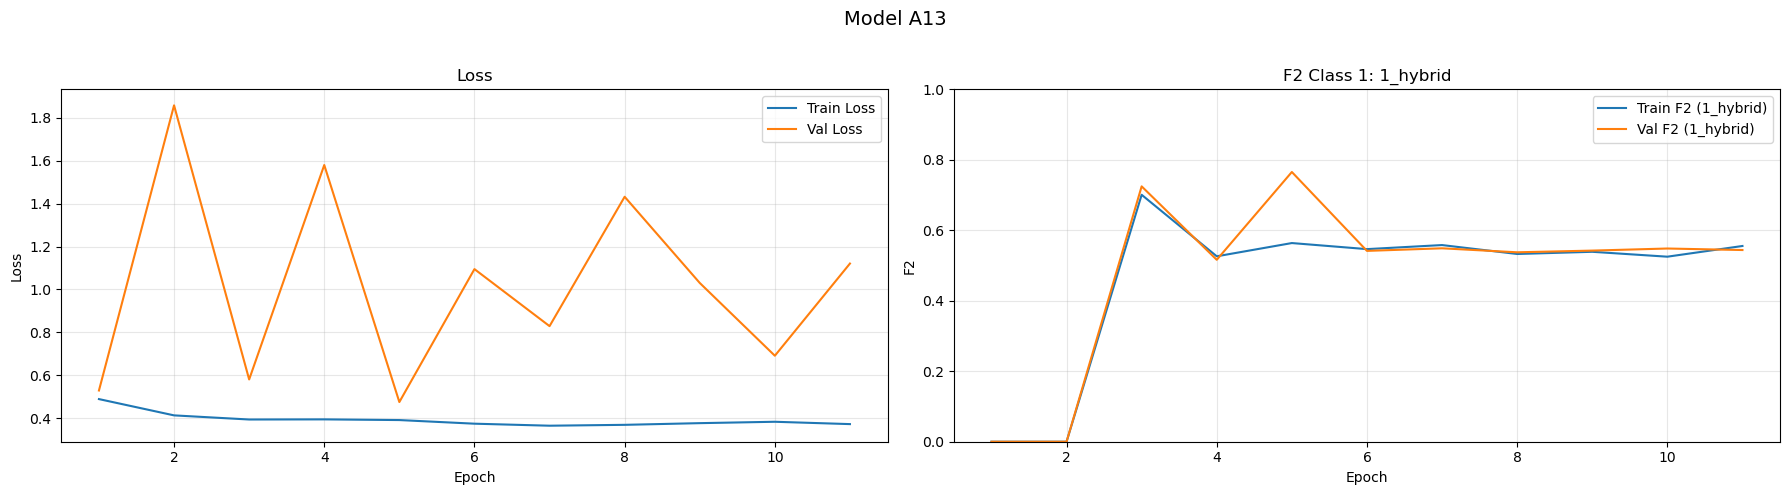

In [12]:
for i in range(1, 14):
    plot_training_curves(model_name=f"Model A{i}", results=results_from_ckpt(model=model_cnn_a_dict[f"model_cnn_a{i}"], ckpt_file=f"../../saved_models/cnn/cnn_a/cnn_model_a{i}_log.pkl"), class_idx=1, class_name="1_hybrid")